# Post-Processing Preview & Dice Check

Compares a model's original prediction against its post-processed ("enhanced") prediction: a visual preview of raw image / ground truth / original prediction / enhanced prediction, plus mean binary dice for both prediction sets against ground truth, as a simple before/after test for `postprocess.enhance_prediction`.

No training or ground truth is involved in producing the enhanced predictions themselves (see `run_postprocessing.py`) -- ground truth is only used here, in this notebook, to score the before/after comparison.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from PIL import Image


def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "lightm-unet").exists() and (candidate / "data").exists():
            return candidate
    return start

REPO_ROOT = _find_repo_root(Path.cwd())

sys.path.insert(0, str(REPO_ROOT / "analysis"))
sys.path.insert(0, str(REPO_ROOT / "post-processing"))
import segmentation_topology as topo
import postprocess
import run_postprocessing as pp_runner

DATASET_DIR = REPO_ROOT / "data" / "nnUNet_raw" / "Dataset501_ARCADE"
IMAGES_TS_DIR = DATASET_DIR / "imagesTs"
LABELS_TS_DIR = DATASET_DIR / "labelsTs"
POSTPROC_DIR = REPO_ROOT / "post-processing"

NET_NAME = "ENetE1"
ORIGINAL_PRED_DIR = DATASET_DIR / f"labelsPr_{NET_NAME}"
ENHANCED_PRED_DIR = POSTPROC_DIR / f"labelsPr_{NET_NAME}_Pp"

CLASS_LABELS = topo.CLASS_LABELS
CLASS_COLORS = ["#000000", "#e6194b", "#3cb44b", "#4363d8"]
CMAP = mcolors.ListedColormap(CLASS_COLORS)
NORM = mcolors.BoundaryNorm(range(len(CLASS_LABELS) + 1), len(CLASS_LABELS))
IMSHOW_MASK_KW = dict(cmap=CMAP, norm=NORM, interpolation="nearest")

print("Repo root         :", REPO_ROOT)
print("Model under test  :", NET_NAME)
print("Original preds    :", ORIGINAL_PRED_DIR)
print("Enhanced preds    :", ENHANCED_PRED_DIR)

Repo root         : C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet
Model under test  : ENetE1
Original preds    : C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\data\nnUNet_raw\Dataset501_ARCADE\labelsPr_ENetE1
Enhanced preds    : C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\post-processing\labelsPr_ENetE1_Pp


## Run post-processing

Regenerates `labelsPr_<NET_NAME>_Pp/` from the current `postprocess.py`, so this notebook always previews/scores whatever the algorithm does right now. Set `RUN_POSTPROCESSING = False` to reuse an existing output folder instead.

In [2]:
RUN_POSTPROCESSING = True

if RUN_POSTPROCESSING:
    pp_runner.run_for_model(NET_NAME)
else:
    print("RUN_POSTPROCESSING=False; using existing enhanced predictions if present.")

if not ENHANCED_PRED_DIR.exists():
    raise FileNotFoundError(
        f"{ENHANCED_PRED_DIR} not found. Run post-processing/run_postprocessing.py "
        f"for {NET_NAME} first, or set RUN_POSTPROCESSING=True above."
    )

ENetE1: 300 cases -> C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\post-processing\labelsPr_ENetE1_Pp


## Build sample index

Matches case IDs across `imagesTs`, `labelsTs` (ground truth), the original `labelsPr_<NET_NAME>`, and the enhanced `labelsPr_<NET_NAME>_Pp`.

In [3]:
gt_paths = {p.stem: p for p in topo.image_files(LABELS_TS_DIR)}
orig_paths = {p.stem: p for p in topo.image_files(ORIGINAL_PRED_DIR)}
enh_paths = {p.stem: p for p in topo.image_files(ENHANCED_PRED_DIR)}
image_paths = {topo.case_id_from_image(p): p for p in topo.image_files(IMAGES_TS_DIR)}

case_ids = sorted(set(gt_paths) & set(orig_paths) & set(enh_paths) & set(image_paths))
print(f"imagesTs found          : {len(image_paths)}")
print(f"labelsTs found          : {len(gt_paths)}")
print(f"Original preds found    : {len(orig_paths)}")
print(f"Enhanced preds found    : {len(enh_paths)}")
print(f"Matched cases           : {len(case_ids)}")

if not case_ids:
    raise FileNotFoundError("No cases matched across imagesTs/labelsTs/original/enhanced predictions.")

imagesTs found          : 300
labelsTs found          : 300
Original preds found    : 300
Enhanced preds found    : 300
Matched cases           : 300


## Loading helpers

In [4]:
def load_raw_image(path: Path) -> np.ndarray:
    return np.asarray(Image.open(path).convert("L"), dtype=np.uint8)


def load_case(case_id: str):
    gt = topo.load_class_id_mask(gt_paths[case_id])
    raw = load_raw_image(image_paths[case_id])
    orig = topo.resize_mask_to(topo.load_class_id_mask(orig_paths[case_id]), gt.shape)
    enh = topo.resize_mask_to(topo.load_class_id_mask(enh_paths[case_id]), gt.shape)
    if raw.shape != gt.shape:
        raw = np.asarray(Image.fromarray(raw).resize((gt.shape[1], gt.shape[0]), Image.BICUBIC), dtype=np.uint8)
    return raw, gt, orig, enh


def legend_handles():
    return [mpatches.Patch(color=CLASS_COLORS[i], label=f"{i}: {CLASS_LABELS[i]}") for i in range(len(CLASS_LABELS))]

## Preview: raw / ground truth / original prediction / enhanced prediction

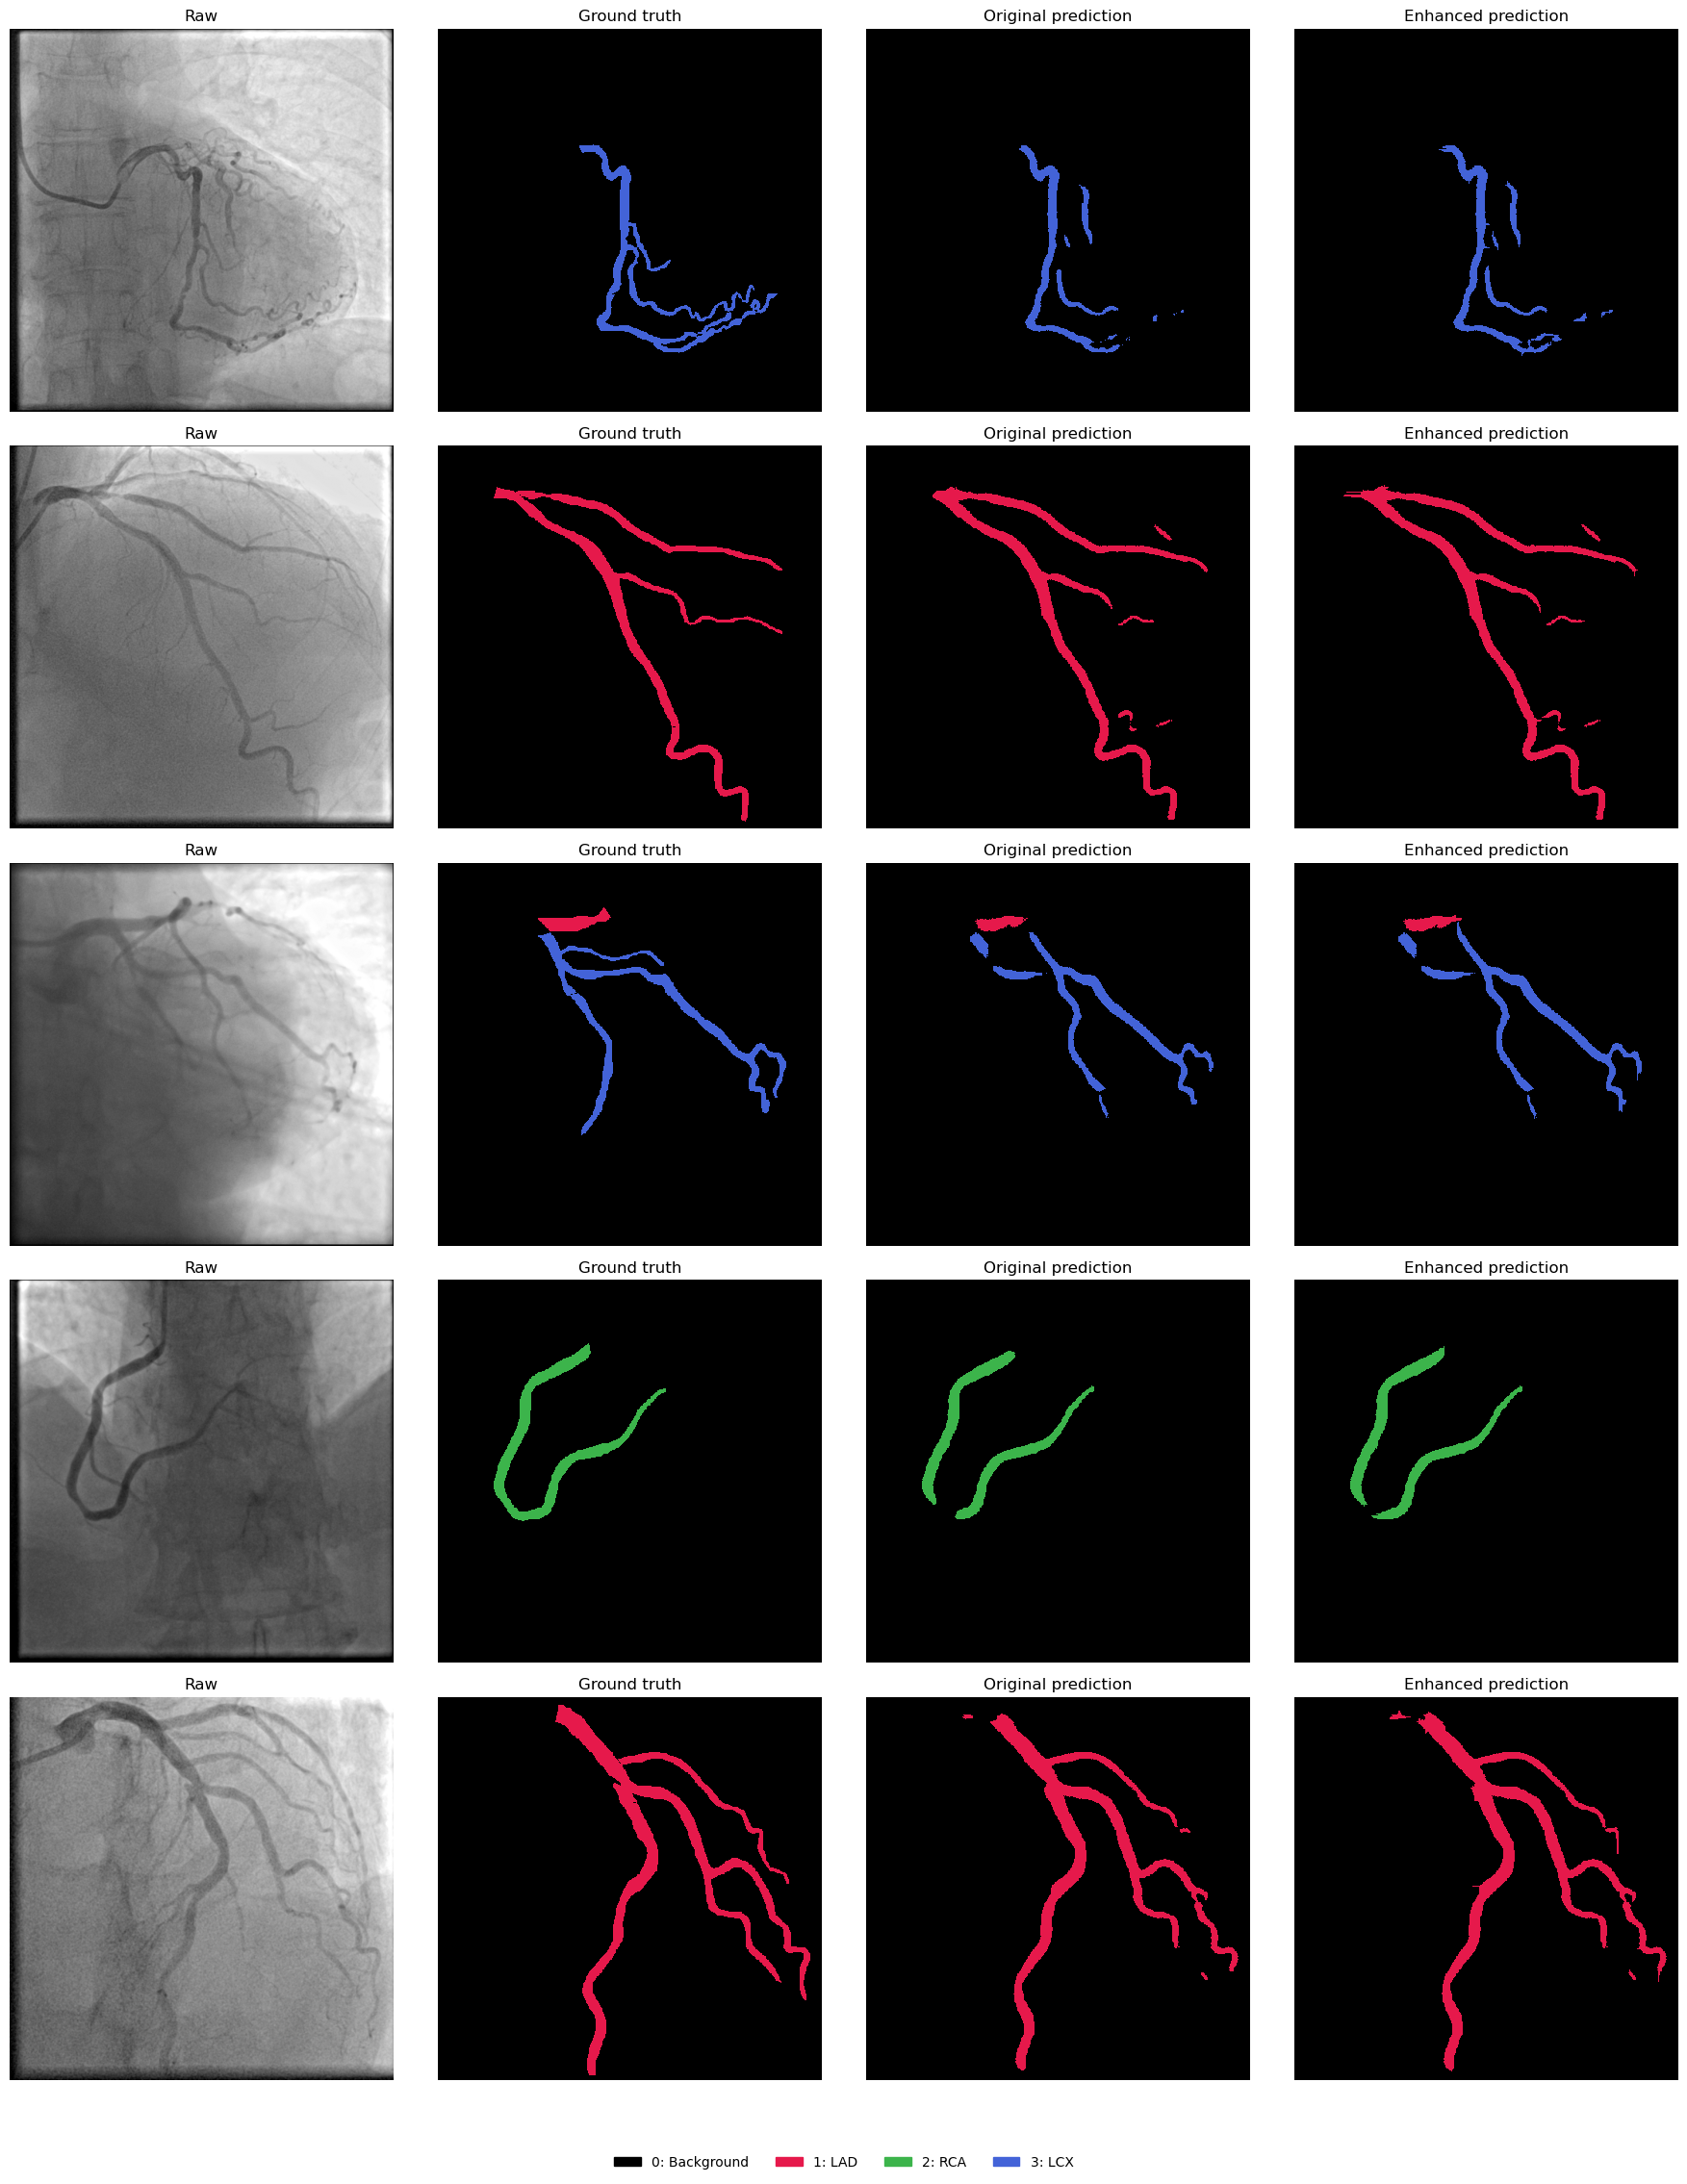

In [5]:
def show_case(case_id: str, ax_row=None):
    raw, gt, orig, enh = load_case(case_id)
    standalone = ax_row is None
    if standalone:
        fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    else:
        axes = ax_row
        fig = axes[0].figure

    axes[0].imshow(raw, cmap="gray"); axes[0].set_title("Raw"); axes[0].axis("off")
    axes[1].imshow(gt, **IMSHOW_MASK_KW); axes[1].set_title("Ground truth"); axes[1].axis("off")
    axes[2].imshow(orig, **IMSHOW_MASK_KW); axes[2].set_title("Original prediction"); axes[2].axis("off")
    axes[3].imshow(enh, **IMSHOW_MASK_KW); axes[3].set_title("Enhanced prediction"); axes[3].axis("off")

    if standalone:
        fig.legend(handles=legend_handles(), loc="lower center", ncol=len(CLASS_LABELS), bbox_to_anchor=(0.5, -0.04), frameon=False)
        fig.suptitle(case_id, fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()


def show_batch(case_ids_subset, save_path: Path | None = None):
    fig, axes = plt.subplots(len(case_ids_subset), 4, figsize=(18, 4.5 * len(case_ids_subset)))
    axes = np.atleast_2d(axes)
    for col, title in enumerate(["Raw", "Ground truth", "Original prediction", "Enhanced prediction"]):
        axes[0, col].set_title(title, fontsize=11, fontweight="bold")
    for row, cid in enumerate(case_ids_subset):
        show_case(cid, ax_row=axes[row])
        axes[row][0].set_ylabel(cid, fontsize=9, rotation=90, labelpad=8)
    fig.legend(handles=legend_handles(), loc="lower center", ncol=len(CLASS_LABELS), bbox_to_anchor=(0.5, -0.01), frameon=False)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print("Saved:", save_path)
    plt.show()

show_batch(case_ids[:5])

## Mean dice: original vs. enhanced predictions

Binary foreground dice (`gt>0` vs `pred>0`) per case, against ground truth, for both the original and enhanced predictions. With the current identity placeholder in `postprocess.py`, `mean_delta` should be exactly 0 -- once `label_1d_segment` is implemented, this is the number that tells you whether it actually helped.

In [6]:
rows = []
for cid in case_ids:
    _, gt, orig, enh = load_case(cid)
    gt_fg = gt > 0
    rows.append({
        "case_id": cid,
        "dice_original": topo.dice_score(gt_fg, orig > 0),
        "dice_enhanced": topo.dice_score(gt_fg, enh > 0),
    })

dice_df = pd.DataFrame(rows)
dice_df["delta"] = dice_df["dice_enhanced"] - dice_df["dice_original"]

summary = pd.DataFrame([{
    "model": NET_NAME,
    "n_cases": len(dice_df),
    "mean_dice_original": dice_df["dice_original"].mean(),
    "mean_dice_enhanced": dice_df["dice_enhanced"].mean(),
    "mean_delta": dice_df["delta"].mean(),
    "n_improved": int((dice_df["delta"] > 1e-9).sum()),
    "n_unchanged": int((dice_df["delta"].abs() <= 1e-9).sum()),
    "n_worsened": int((dice_df["delta"] < -1e-9).sum()),
}])

print("Mean dice: original vs. enhanced")
display(summary)
print("Per-case dice (head)")
display(dice_df.head())

out_path = POSTPROC_DIR / f"{NET_NAME}_dice_before_after.csv"
dice_df.to_csv(out_path, index=False)
print("Saved:", out_path)

Mean dice: original vs. enhanced


,model,n_cases,mean_dice_original,mean_dice_enhanced,mean_delta,n_improved,n_unchanged,n_worsened
0,ENetE1,300,0.746682,0.748503,0.001821,167,7,126


Per-case dice (head)


,case_id,dice_original,dice_enhanced,delta
0,test_1,0.699697,0.728124,0.028427
1,test_10,0.887806,0.887719,-0.000088
2,test_100,0.585569,0.597242,0.011673
3,test_101,0.917015,0.929126,0.012111
4,test_102,0.878902,0.882551,0.003649


Saved: C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\post-processing\ENetE1_dice_before_after.csv
